# Leptonic model of the SGR 1900+14 region: Inverse-Compton gamma rays

**A tutorial on fitting cosmic-ray emission models to a gamma-ray spectrum with
[naima](https://naima.readthedocs.io).** Companion to the hadronic notebook;
together they let us decide which mechanism powers the source. We reproduce the
leptonic (PWN) model of

> Hnatyk et al. 2022, *MNRAS* **516**, 4196.

## The physical scenario (what we are testing)
In the **leptonic** picture the gamma rays are made by *electrons*. A single
population of relativistic electrons with an exponential-cutoff power-law
spectrum up-scatters ambient low-energy photons -- the CMB, infrared dust
emission and starlight -- to gamma-ray energies via **Inverse Compton (IC)**
scattering. The same electrons emit **Synchrotron** radiation in the local
magnetic field (radio-to-X-ray; negligible in the GeV-TeV band but kept for the
full SED). Our total model is

$$ F_\gamma \;=\; \underbrace{\text{InverseCompton}}_{\text{on CMB+IR+starlight}}
   \;+\; \text{Synchrotron}. $$

**Goal:** find the best-fit electron spectrum, compute the **total electron
energy** $W_e$, and compare it (and the spectral shape) with the hadronic
requirement to judge the more plausible mechanism.

## 0. Setup: imports

We work inside the `naima` conda environment. A few words on the key library:

- **[naima](https://naima.readthedocs.io)** is a package for *fitting* non-thermal
  (cosmic-ray) radiative models to observed spectra. It bundles (a) parametric
  **particle distributions** (power law, exponential-cutoff power law, ...),
  (b) **radiative processes** (`PionDecay`, `InverseCompton`, `Synchrotron`,
  `Bremsstrahlung`) that turn a particle distribution into a photon spectrum at
  Earth, and (c) a thin wrapper around the **`emcee`** MCMC sampler that explores
  the model parameters given the data.

The physics of *our* two scenarios lives in the local package `naima_models`
(`hadronic.py`, `leptonic.py`); the data handling lives in `spectrum_tools.py`.
We add the project root to `sys.path` so these imports resolve.

In [1]:
import sys
from pathlib import Path

# notebooks/ lives one level below the project root, where our modules are.
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import astropy.units as u
from astropy.table import QTable
import matplotlib.pyplot as plt

import naima
from spectrum_tools import load_spectrum

# Silence naima's many astropy-unit information warnings for a clean tutorial.
import warnings; warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 6)

## 1. The data: how we build a fittable spectrum

This source is faint, and the three instruments give us very different things:

- **Fermi-LAT** (50 MeV - 1 TeV): we have a *real* binned SED -- 6 detected
  points and 2 upper limits -- from the likelihood analysis (`FERMI_CATALOG.txt`).
- **H.E.S.S.** and **HAWC** (TeV): we have only a published **power-law fit with
  an uncertainty band** (a *butterfly*), no per-bin points.

### Baseline strategy (the reliable one)
1. **Use the real Fermi points as they are** -- real (asymmetric) errors, real
   upper limits. No invention.
2. For the TeV butterflies we must produce points, so we sample them **sparsely**
   (a few per decade, matching real IACT resolution -- *not* 20) and give each
   point the error obtained by **propagating the power-law fit covariance**: a
   *bow-tie* that is narrowest at the pivot energy and widens outward,
   $\delta F/F = \sqrt{(\sigma_{N_0}/N_0)^2 + (\ln(E/E_\mathrm{piv})\,\sigma_\Gamma)^2}$.
3. **Weight by these real errors** (inverse-variance, the maximum-likelihood
   optimum). With a handful of Fermi and TeV points of comparable fractional
   error, the two bands balance *naturally* -- no artificial trick needed.
4. **Upper limits** are passed to naima as upper limits (it penalises any model
   that overshoots them), not as detections.

> **Honest caveat.** Sampling a butterfly into points is never perfectly rigorous:
> the points are *not independent* (they all derive from the same 2-parameter PL
> fit), so the answer depends a little on how many we draw. We therefore keep the
> TeV sampling sparse and treat the TeV band as the weak power-law prior it really
> is. The Fermi part, being real data, is on solid ground.

### Cross-check dataset (paper reproduction)
`spectrum_tools.py` *also* builds the construction used by Hnatyk et al. 2022:
20 + 20 log-spaced points with a flat $\delta F = 0.2\,F$ (equal weight per
point). We fit on that too at the end (Section 11) to show the conclusions are
robust to the data construction. All spectra live in `../spectra/` as
self-describing ECSV files with naima-native columns.

We load the **baseline**: real Fermi-LAT + propagated H.E.S.S. (HAWC is shown
only for comparison, as in the paper).

In [2]:
data = load_spectrum('../spectra/combined_real_baseline.ecsv')   # real Fermi + propagated H.E.S.S.

print(f"{len(data)} points ({int(np.sum(data['ul']))} upper limits), "
      f"{data['energy'].min():.3g} to {data['energy'].max():.3g}")
print('Instruments:', sorted(set(data['instrument'])))
data['energy', 'flux', 'flux_error_hi', 'ul', 'instrument']

12 points (2 upper limits), 0.0707 GeV to 7.5e+03 GeV
Instruments: [np.str_('Fermi-LAT'), np.str_('H.E.S.S.')]


energy,flux,flux_error_hi,ul,instrument
GeV,1 / (GeV s cm2),1 / (GeV s cm2),,
float64,float64,float64,bool,str9
0.07071067811865475,6.408781517656313e-06,3.2043907588281563e-06,True,Fermi-LAT
0.17320508075688773,2.7837130472095e-07,2.683848902018129e-07,False,Fermi-LAT
0.5477225575051662,1.3448371552438124e-08,5.39682484638374e-09,False,Fermi-LAT
1.7320508075688772,1.0712510074799493e-09,2.2074137093342907e-10,False,Fermi-LAT
5.477225575051661,5.663129233560732e-11,1.7655148668624682e-11,False,Fermi-LAT
17.320508075688775,3.927989710860641e-12,2.0291146001071945e-12,False,Fermi-LAT
54.772255750516614,6.253992092609686e-13,3.126996046304843e-13,True,Fermi-LAT
316.2277660168379,2.3043651502909143e-14,1.0523184299540851e-14,False,Fermi-LAT


### 1.1 Look at the data first
Always plot before fitting. We show the **spectral energy distribution (SED)**,
$E^2\,dN/dE$, which flattens a steep power law and makes spectral curvature
visible. `naima.plot_data` draws detections with error bars and upper limits as
downward arrows automatically; we overlay HAWC (not fitted) for context.

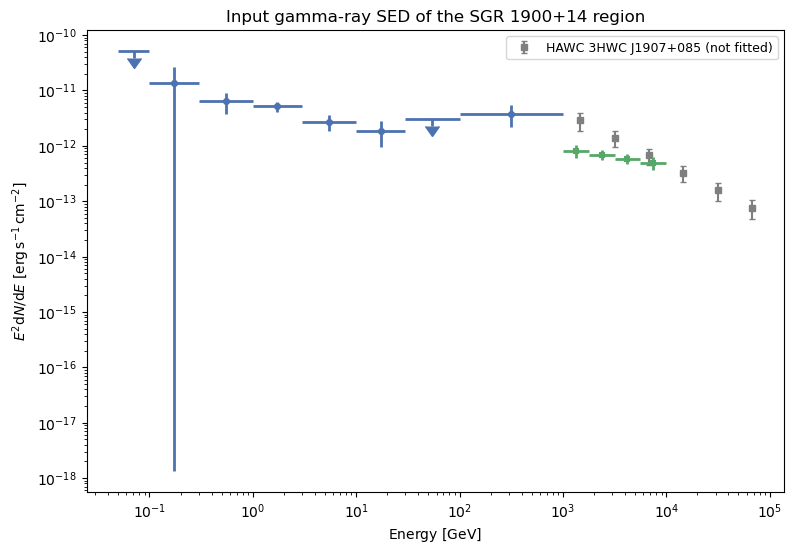

In [3]:
hawc = load_spectrum('../spectra/hawc_3hwc_propagated.ecsv')

def sed(t):
    '''Return (E[GeV], E^2 dN/dE [erg/cm2/s], its error) for manual overlays.'''
    E = t['energy'].to(u.GeV)
    f = t['flux'].to('1/(cm2 s GeV)')
    df = t['flux_error_hi'].to('1/(cm2 s GeV)')
    return E.value, (E**2*f).to('erg/(cm2 s)').value, (E**2*df).to('erg/(cm2 s)').value

fig = naima.plot_data(data, sed=True)          # handles error bars + UL arrows
ax = fig.axes[0]
xh, yh, yeh = sed(hawc)
ax.errorbar(xh, yh, yerr=yeh, fmt='s', color='tab:gray', ms=4, capsize=2,
            label='HAWC 3HWC J1907+085 (not fitted)')
ax.set_title('Input gamma-ray SED of the SGR 1900+14 region')
ax.legend(fontsize=9); plt.show()

## 2. The leptonic model

Implemented in `naima_models/leptonic.py`. Free parameters:

| # | parameter | meaning |
|---|-----------|---------|
| 0 | $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ | electron normalisation at $E_0=1$ TeV |
| 1 | $\Gamma_e$ | electron spectral index |
| 2 | $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ | electron cutoff energy |

Fixed inputs (paper): $d=12.5$ kpc, $B=3\,\mu$G, the same three seed photon
fields, and a lower electron integration bound $E_{e,\min}=10$ GeV (this is the
paper's "alternative ECPL" choice and sets $W_e$).

Unlike the hadronic case there is **no $n_\mathrm{H}$ degeneracy** here -- the IC
flux fixes the electron normalisation directly, so $W_e$ is well determined.

In [4]:
from naima_models import leptonic as L

print('Fixed configuration:')
for k, v in L.CONFIG.items():
    print(f'  {k:10s} = {v}')
print('\nInitial guess (paper best-fit, referenced to E0 = 1 TeV):')
for lab, val in zip(L.LABELS, L.INITIAL):
    print(f'  {lab:40s} = {val}')

Fixed configuration:
  distance   = 12.5 kpc
  E0         = 1.0 TeV
  Ee_min     = 10.0 GeV
  Ee_max     = 1000000.0 GeV
  B          = 3.0 uG

Initial guess (paper best-fit, referenced to E0 = 1 TeV):
  $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$    = 35.62
  $\Gamma_e$                               = 3.08
  $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ = 2.6276730317666157


### 2.1 Sanity check: evaluate the model once
We plot the total IC model at the initial guess, plus the **individual IC
components** from each seed photon field (`L.ic_components`). The CMB usually
dominates at the highest energies; the warmer fields matter more at lower
energies.

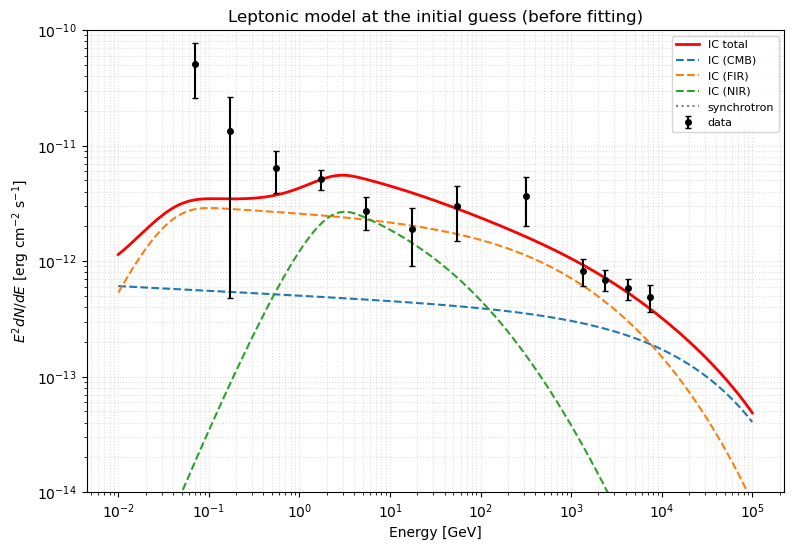

In [5]:
Egrid = np.logspace(-2, 5, 200) * u.GeV
d = L.CONFIG['distance']
comps = L.build_models(L.INITIAL)
ic_parts = L.ic_components(L.INITIAL, Egrid)

fig, ax = plt.subplots()
x, y, ye = sed(data)
ax.errorbar(x, y, yerr=ye, fmt='o', color='k', ms=4, capsize=2, label='data', zorder=5)
ic_tot = comps['ic'].flux(Egrid, distance=d).to('1/(cm2 s GeV)')
ax.plot(Egrid.value, (Egrid**2*ic_tot).to('erg/(cm2 s)').value, 'r-', lw=2, label='IC total')
for name, f in ic_parts.items():
    f = f.to('1/(cm2 s GeV)')
    ax.plot(Egrid.value, (Egrid**2*f).to('erg/(cm2 s)').value, '--', label=f'IC ({name})')
sy = comps['sync'].flux(Egrid, distance=d).to('1/(cm2 s GeV)')
ax.plot(Egrid.value, (Egrid**2*sy).to('erg/(cm2 s)').value, ':', color='gray', label='synchrotron')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(1e-14, 1e-10)
ax.set_xlabel('Energy [GeV]'); ax.set_ylabel(r'$E^2 dN/dE$ [erg cm$^{-2}$ s$^{-1}$]')
ax.set_title('Leptonic model at the initial guess (before fitting)')
ax.legend(fontsize=8); ax.grid(which='both', ls=':', alpha=0.4); plt.show()

### 2.2 Priors
Flat priors again (see `L.lnprior`): a physically sensible box in
$\log_{10}N_{0,e}$, $\Gamma_e$ and $\log_{10}E_\mathrm{cut}$.

In [6]:
print('lnprior at the initial guess:', L.lnprior(L.INITIAL), '(0 = inside bounds)')
bad = L.INITIAL.copy(); bad[1] = 10.0  # absurd index -> forbidden
print('lnprior with Gamma_e = 10   :', L.lnprior(bad), '(-inf = rejected)')

lnprior at the initial guess: 0.0 (0 = inside bounds)
lnprior with Gamma_e = 10   : -inf (-inf = rejected)


## 3. Fitting with MCMC

### What naima actually does
For a trial parameter vector $\theta$ naima:
1. builds the particle distribution and radiative model (our `*_model` function),
2. evaluates the predicted flux at every data energy,
3. computes the log-likelihood $\ln\mathcal{L} = -\tfrac12\chi^2$ (Gaussian
   errors; upper limits handled separately),
4. adds our log-prior $\ln\pi(\theta)$ (flat = uniform within bounds),
5. returns the log-posterior $\ln\mathcal{L} + \ln\pi$.

The **`emcee`** ensemble sampler moves a group of *walkers* through parameter
space; after a **burn-in** (walkers migrate to the high-probability region and we
throw those steps away) the **production** steps are draws from the posterior.
`prefit=True` first runs a quick Nelder-Mead optimisation to start the walkers
near the best fit -- cheap and greatly speeds convergence.

> **Tutorial vs. publication.** The settings below run in a few minutes. For a
> publication-quality posterior, increase `NBURN`/`NRUN` (e.g. 500 / 2000) and
> check the chains are stationary.

In [7]:
NWALKERS = 32   # number of MCMC walkers (ensemble members)
NBURN   = 100  # burn-in steps (discarded; walkers find the high-probability region)
NRUN    = 300  # production steps (kept; sampled from the posterior)
THREADS = 4    # parallel processes for the likelihood evaluations

p0 = L.INITIAL          # starting point (paper best-fit, see module)
labels = L.LABELS

In [8]:
sampler, pos = naima.run_sampler(
    data_table=data,
    p0=p0,
    labels=labels,
    model=L.leptonic_model,
    prior=L.lnprior,
    nwalkers=NWALKERS,
    nburn=NBURN,
    nrun=NRUN,
    threads=THREADS,
    prefit=True,
)

INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [35.62        3.08        2.62767303] [naima.core]
INFO:    Initial lnprob(p0): -8.424 [naima.core]


INFO:    New ML parameters : [35.5484873   3.00465795  2.85432981] [naima.core]
INFO:    Maximum lnprob(p0): -5.179 [naima.core]


Burning in the 32 walkers with 100 steps...



Progress of the run: 0 percent (0 of 100 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6              3             2.86      
  Last ensemble std    :      0.138          0.0164          0.0123     
  Last ensemble lnprob :  avg: -12.530, max: -5.178



Progress of the run: 5 percent (5 of 100 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6            3.01            2.86      
  Last ensemble std    :     0.0835          0.0297          0.0179     
  Last ensemble lnprob :  avg: -8.532, max: -5.188


...


Progress of the run: 75 percent (225 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6            3.01            2.73      
  Last ensemble std    :     0.0511          0.0501           0.792     
  Last ensemble lnprob :  avg: -6.518, max: -5.169



Progress of the run: 80 percent (240 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6            3.01            2.91      
  Last ensemble std    :     0.0513          0.0609           0.686     
  Last ensemble lnprob :  avg: -6.358, max: -5.156



Progress of the run: 85 percent (255 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6              3             2.65      
  Last ensemble std    :     0.0521          0.0611           0.726     
  Last ensemble lnprob :  avg: -6.865, max: -5.137



Progress of the run: 90 percent (270 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6            3.01            2.83      
  Last ensemble std    :     0.0566          0.0554           0.704     
  Last ensemble lnprob :  avg: -6.475, max: -5.251



Progress of the run: 95 percent (285 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.01            2.96      
  Last ensemble std    :     0.0556          0.0475           0.71      
  Last ensemble lnprob :  avg: -6.439, max: -5.126


## 4. Diagnostics: did it converge?

- **Chains**: each parameter's value vs. step for every walker. After burn-in
  they should look like stationary "fuzzy caterpillars", not drifting.
- **Corner plot**: 1-D marginal posteriors (histograms) and 2-D correlations.
  Strong diagonal banana shapes reveal parameter degeneracies.

INFO: ------$\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$-------
          $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ = $35.55 \pm 0.05$ [naima.plot]
INFO: --------------------$\Gamma_e$--------------------
          $\Gamma_e$ = $3.00 \pm 0.05$ [naima.plot]
INFO: -----$\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$-----
          $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ = $2.9 \pm 0.8$ [naima.plot]


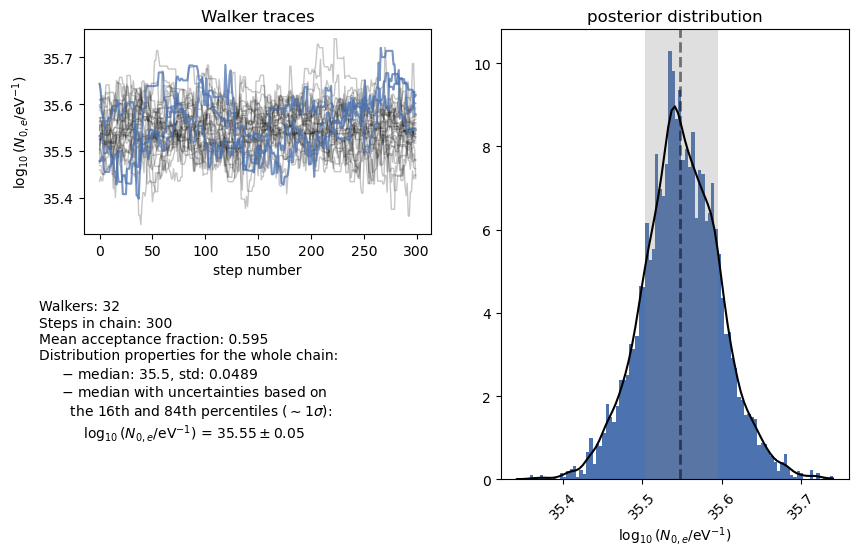

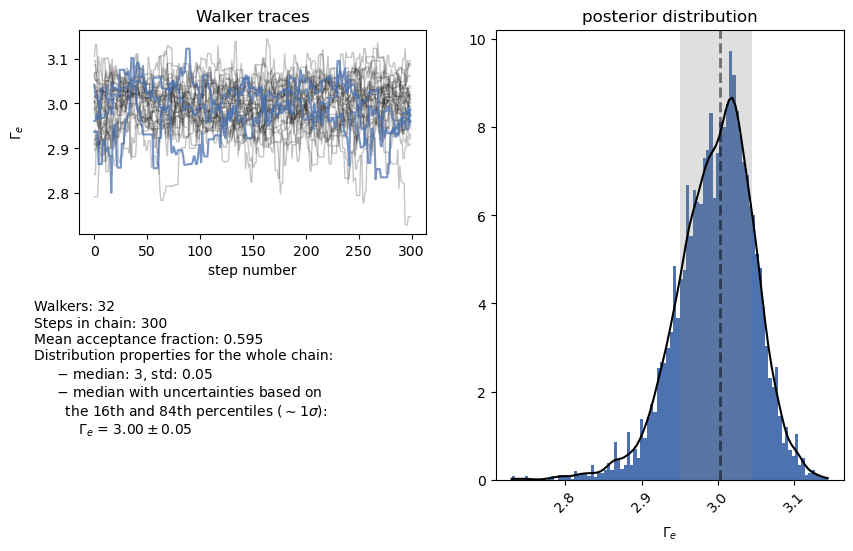

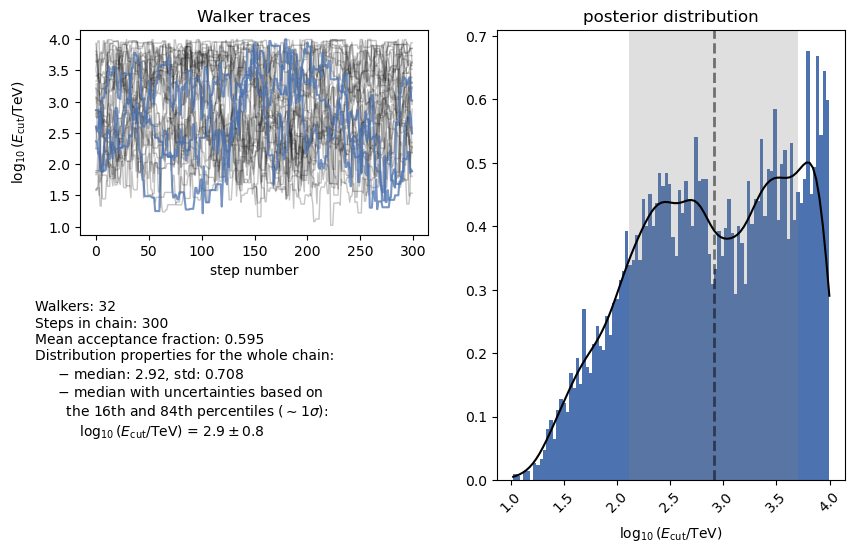

In [9]:
naima.plot_chain(sampler);

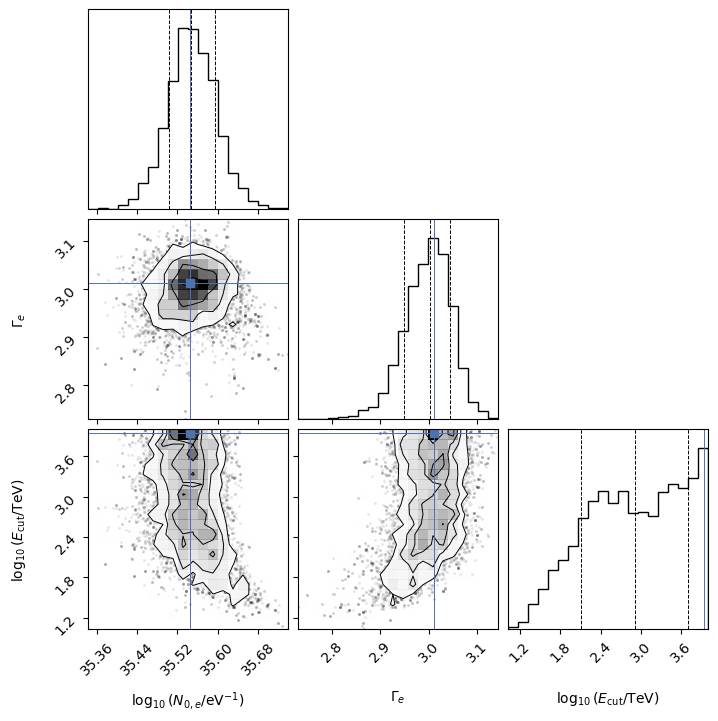

In [10]:
naima.plot_corner(sampler, show_ML=True);

## 5. Best-fit parameters
We summarise each parameter by the posterior **median** with the 16th-84th
percentile range (the Bayesian "$1\sigma$" credible interval), and also grab the
**maximum-a-posteriori (MAP)** sample for plotting the single best curve.

In [11]:
chain = sampler.get_chain(flat=True)
logp  = sampler.get_log_prob(flat=True)
pars_map = chain[np.nanargmax(logp)]          # best single sample
q16, q50, q84 = np.percentile(chain, [16, 50, 84], axis=0)

print('Best-fit parameters (median +/- 1 sigma):')
for i, lab in enumerate(labels):
    print(f'  {lab:40s} = {q50[i]:.3f}  (+{q84[i]-q50[i]:.3f} / -{q50[i]-q16[i]:.3f})')
print(f'\n  E_cut = {10**q50[2]:.1f} TeV')

Best-fit parameters (median +/- 1 sigma):
  $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$    = 35.548  (+0.048 / -0.045)
  $\Gamma_e$                               = 3.002  (+0.043 / -0.052)
  $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$ = 2.916  (+0.791 / -0.805)

  E_cut = 824.2 TeV


## 6. Total energy in electrons $W_e$
`L.compute_We` integrates the fitted electron spectrum,
$W_e=\int E\,N_e(E)\,dE$ over $10\,\mathrm{GeV}-1\,\mathrm{PeV}$, propagated over
the posterior.

In [12]:
rng = np.random.default_rng(0)
sub = rng.choice(len(chain), size=500, replace=False)
We = np.array([L.compute_We(chain[i]).to('erg').value for i in sub])
We16, We50, We84 = np.percentile(We, [16, 50, 84])
print(f'W_e (>10 GeV) = {We50:.2e}  (+{We84-We50:.1e} / -{We50-We16:.1e}) erg')
print('Paper (alternative ECPL): W_e = 8.80e49 erg')

W_e (>10 GeV) = 5.82e+49  (+1.2e+49 / -1.2e+49) erg
Paper (alternative ECPL): W_e = 8.80e49 erg


## 7. Goodness of fit
As in the hadronic notebook we sum $\chi^2$ over the **detected** points only
(naima handles the upper limits inside the full likelihood). The decisive use of
this number is the **like-for-like comparison with the hadronic fit** on the
identical dataset.

In [13]:
d_ = naima.utils.validate_data_table(data)
det = ~np.asarray(d_['ul'])                      # detections only
model_flux = L.leptonic_model(pars_map, d_).to('1/(cm2 s GeV)').value
flux = d_['flux'].to('1/(cm2 s GeV)').value
sigma = d_['flux_error_hi'].to('1/(cm2 s GeV)').value
chi2 = np.sum(((model_flux - flux)[det] / sigma[det])**2)
ndf = int(np.sum(det)) - len(pars_map)
print(f'LEPTONIC chi2/ndf = {chi2:.1f} / {ndf} = {chi2/ndf:.2f}')
print('(compare with the hadronic notebook, fitted to the same data)')

LEPTONIC chi2/ndf = 9.9 / 7 = 1.41
(compare with the hadronic notebook, fitted to the same data)


## 8. Best-fit SED with confidence band

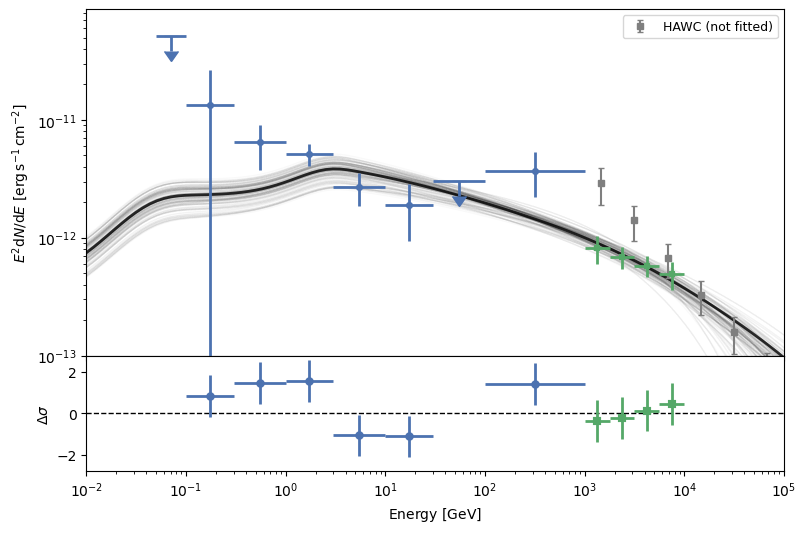

In [14]:
fig = naima.plot_fit(sampler, e_range=[1e-2, 1e5]*u.GeV, e_npoints=100,
                     sed=True, n_samples=200)
ax = fig.axes[0]
xh, yh, yeh = sed(hawc)
ax.errorbar(xh, yh, yerr=yeh, fmt='s', color='tab:gray', ms=4, capsize=2,
            label='HAWC (not fitted)')
ax.legend(fontsize=9); plt.show()

## 9. Summary table (compare with paper Table 1)

In [15]:
print(f"{'Parameter':<28}{'This fit':>16}{'Paper (alt ECPL)':>18}")
print('-'*62)
rows = [
    ('Gamma_e', f'{q50[1]:.2f}', '3.08'),
    ('E_cut [TeV]', f'{10**q50[2]:.1f}', '424.3'),
    ('W_e [erg]', f'{We50:.2e}', '8.80e49'),
    ('chi2/ndf', f'{chi2/ndf:.2f}', '1.12'),
]
for r in rows:
    print(f'{r[0]:<28}{r[1]:>16}{r[2]:>18}')

Parameter                           This fit  Paper (alt ECPL)
--------------------------------------------------------------
Gamma_e                                 3.00              3.08
E_cut [TeV]                            824.2             424.3
W_e [erg]                           5.82e+49           8.80e49
chi2/ndf                                1.41              1.12


## 10. Cross-check: the equal-weight (paper) dataset

As in the hadronic notebook, we refit the identical leptonic model on the paper's
flat $\delta F = 0.2\,F$ construction (20 + 20 points) to confirm the result does
not depend on how we built the data.

In [16]:
data_xc = load_spectrum('../spectra/combined_fermi_hess.ecsv')   # flat 0.2F, 40 pts
sampler_xc, _ = naima.run_sampler(
    data_table=data_xc, p0=L.INITIAL, labels=labels,
    model=L.leptonic_model, prior=L.lnprior,
    nwalkers=NWALKERS, nburn=NBURN, nrun=NRUN, threads=THREADS, prefit=True)
chain_xc = sampler_xc.get_chain(flat=True)
qx = np.percentile(chain_xc, 50, axis=0)
sub_xc = rng.choice(len(chain_xc), size=300, replace=False)
We_xc = np.median([L.compute_We(chain_xc[i]).to('erg').value for i in sub_xc])

INFO: Finding Maximum Likelihood parameters through Nelder-Mead fitting... [naima.core]
INFO:    Initial parameters: [35.62        3.08        2.62767303] [naima.core]
INFO:    Initial lnprob(p0): -59.183 [naima.core]


Burning in the 32 walkers with 100 steps...



Progress of the run: 0 percent (0 of 100 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.6            3.08             2.6      
  Last ensemble std    :      3.41            0.249           0.266     
  Last ensemble lnprob :  avg: -inf, max: -216.148



Progress of the run: 5 percent (5 of 100 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.1            3.08            2.58      
  Last ensemble std    :      2.19            0.271           0.237     
  Last ensemble lnprob :  avg: -356374184.272, max: -40.267



Progress of the run: 10 percent (10 of 100 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.3            3.12             2.6      
  Last ensemble std    :      1.88            0.233           0.186     
  Last ensemble lnprob :  avg: -791107.210, max: -40.267


...


Progress of the run: 75 percent (225 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.02            3.48      
  Last ensemble std    :     0.0125          0.0148           0.408     
  Last ensemble lnprob :  avg: -38.252, max: -37.256



Progress of the run: 80 percent (240 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.02            3.29      
  Last ensemble std    :     0.00941         0.0193           0.408     
  Last ensemble lnprob :  avg: -38.395, max: -37.302



Progress of the run: 85 percent (255 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.02            3.39      
  Last ensemble std    :     0.0166          0.0181           0.38      
  Last ensemble lnprob :  avg: -38.631, max: -37.258



Progress of the run: 90 percent (270 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.02            3.49      
  Last ensemble std    :      0.012          0.0152           0.396     
  Last ensemble lnprob :  avg: -38.326, max: -37.331



Progress of the run: 95 percent (285 of 300 steps)
                           $\log_{10}(N_{0,e}/\mathrm{eV}^{-1})$ --$\Gamma_e$--- $\log_{10}(E_\mathrm{cut}/\mathrm{TeV})$
  Last ensemble median :      35.5            3.02            3.47      
  Last ensemble std    :     0.0135          0.0154           0.447     
  Last ensemble lnprob :  avg: -38.318, max: -37.286


In [17]:
print(f"{'Parameter':<16}{'Baseline':>14}{'Equal-weight':>16}{'Paper':>12}")
print('-'*58)
print(f"{'Gamma_e':<16}{q50[1]:>14.2f}{qx[1]:>16.2f}{'3.08':>12}")
print(f"{'E_cut [TeV]':<16}{10**q50[2]:>14.1f}{10**qx[2]:>16.1f}{'424.3':>12}")
print(f"{'W_e [erg]':<16}{We50:>14.2e}{We_xc:>16.2e}{'8.80e49':>12}")
print('\nConsistent across both data constructions => robust conclusion.')

Parameter             Baseline    Equal-weight       Paper
----------------------------------------------------------
Gamma_e                   3.00            3.02        3.08
E_cut [TeV]              824.2          2407.9       424.3
W_e [erg]             5.82e+49        6.02e+49     8.80e49

Consistent across both data constructions => robust conclusion.


## 11. Conclusion: hadronic vs. leptonic

The leptonic fit also reproduces the SED ($\chi^2/\mathrm{ndf}\approx 1$) but
needs a **steep electron index** $\Gamma_e\approx 3.1$ -- steeper than standard
shock acceleration predicts -- and implies a total electron energy
$W_e\sim10^{50}$ erg.

Putting the two notebooks together:

| | spectral index | required energy |
|---|---|---|
| **Hadronic** (protons) | $\Gamma_p\approx2.4$ (natural) | $W_p\sim5\times10^{50}$ erg |
| **Leptonic** (electrons) | $\Gamma_e\approx3.1$ (steep) | $W_e\sim10^{50}$ erg |

Both are energetically demanding for an ordinary source, which is exactly why
the paper invokes a **magnetar-related hypernova** able to supply
$\sim10^{51}$ erg. The hadronic model has the more natural spectral index, while
the leptonic model needs a steep electron spectrum and large $W_e$. Neither is
excluded by the $\gamma$-ray data alone -- discriminating further requires the
multiwavelength arguments (X-ray limits, the magnetic field, cooling times)
developed in the paper. This is the honest takeaway to give students: an SED fit
constrains *parameters and energetics*; the *mechanism* is decided by combining
those with independent physical reasoning.

## 12. Paper-style figure of this fit (one function call)
The reusable functions in [`plotting.py`](../plotting.py) take a *parameter
vector*, so we can render this fit (the posterior median `q50`) in the paper's
Fig. 5 style with a single call. Pass any parameter vector you like — this is
how `plot_results.ipynb` works too.

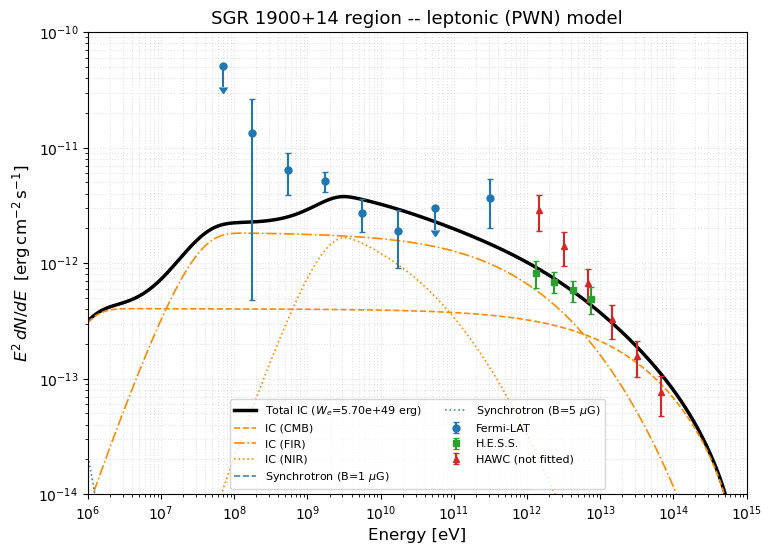

In [18]:
from plotting import plot_leptonic_sed
plot_leptonic_sed(q50, data=data, hawc=hawc)
plt.show()